In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler

# Gradient Descent
Scikit-learn has a gradient descent regression model [sklearn.linear_model.SGDRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html#examples-using-sklearn-linear-model-sgdregressor).  Like your previous implementation of gradient descent, this model performs best with normalized inputs. [sklearn.preprocessing.StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler) will perform z-score normalization as in a previous lab. Here it is referred to as 'standard score'.

## Load the dataset

In [43]:
columns = ["Size(sqft)","Number of Bedrooms","Number of floors","Age of Home","Price (1000s dollars)"]
df = pd.read_csv(r"E:\SALEH\Data\houses.txt",names=columns)

In [44]:
df.head()

,Size(sqft),Number of Bedrooms,Number of floors,Age of Home,Price (1000s dollars)
0,952.0,2.0,1.0,65.0,271.5
1,1244.0,3.0,1.0,64.0,300.0
2,1947.0,3.0,2.0,17.0,509.8
3,1725.0,3.0,2.0,42.0,394.0
4,1959.0,3.0,2.0,15.0,540.0


In [45]:
X_train = df.drop(['Price (1000s dollars)'],axis=1)
y_train = df['Price (1000s dollars)']

# feature scaling using sikit-learn

In [46]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_train)

# Create an fit the model

In [48]:
sgdr = SGDRegressor(max_iter= 1000)
sgdr.fit(X_scaled,y_train)
print(sgdr)
print(f"num of iteration = {sgdr.n_iter_} num of weight update {sgdr.t_}")

SGDRegressor()
num of iteration = 143 num of weight update 14301.0


# model parameter

In [49]:
b_norm = sgdr.intercept_
w_norm = sgdr.coef_

In [51]:
print(f"model parameters:                   w: {w_norm}, b:{b_norm}")

model parameters:                   w: [110.38219565 -21.35389063 -32.52329913 -37.81784132], b:[362.24358781]


# Make predictions
Predict the targets of the training data. Use both the `predict` routine and compute using $w$ and $b$.

In [54]:
y_pred_sgd = sgdr.predict(X_scaled)
y_pred = np.dot(X_scaled,w_norm) + b_norm

print(f"prediction using np.dot() and sgdr.predict match: {(y_pred == y_pred_sgd).all()}")

print(f"Prediction on training set:\n{y_pred[:4]}" )

print(f"Target values \n{y_train[:4]}")

prediction using np.dot() and sgdr.predict match: True
Prediction on training set:
[248.64220844 295.58735856 485.78271751 389.66339543]
Target values 
0    271.5
1    300.0
2    509.8
3    394.0
Name: Price (1000s dollars), dtype: float64


# plot 

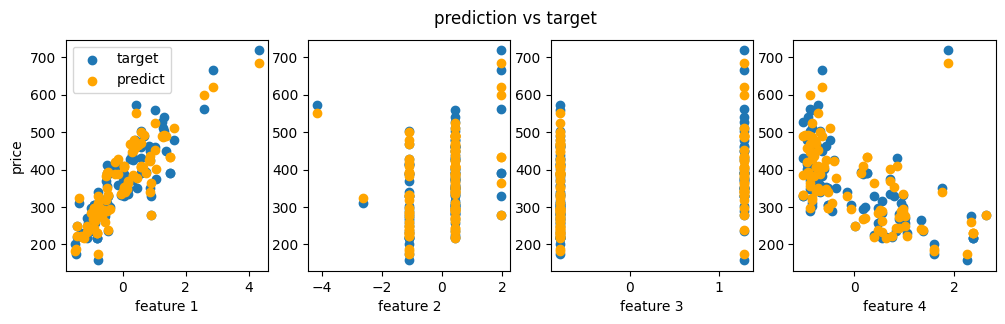

In [68]:
m = X_scaled.shape[0]
yp = np.zeros(m)
yp = X_scaled @ w_norm + b_norm # the @ matrix multiplication
yp = yp.flatten() 

fig,ax = plt.subplots(1,4,figsize = (12,3))

for i in range(X_scaled.shape[1]):
    ax[i].scatter(X_scaled[:,i],y_train,label = "target")
    ax[i].scatter(X_scaled[:,i], yp,color = 'orange',label = "predict")
    ax[i].set_xlabel(f"feature {i+1}")

ax[0].set_ylabel("price")
ax[0].legend()
plt.suptitle("prediction vs target")
plt.show()
    


In [ ]:
yp